# 04 – Class Balancing: Oversampling / Undersampling

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Corregir el desbalance de clases en el conjunto de entrenamiento para evitar que el modelo aprenda a predecir siempre la clase mayoritaria.

> ⚠️ El balanceo se aplica **solo** al conjunto de entrenamiento (`X_train`, `y_train`). El conjunto de prueba permanece intacto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print('imbalanced-learn no está instalado. Se usará numpy para el ejemplo.')

# ─── Cargar datos de entrenamiento ────────────────────────────────────────────
SPLIT_DIR = os.path.join('..', 'data', 'split')
try:
    X_train = pd.read_csv(os.path.join(SPLIT_DIR, 'X_train.csv'))
    y_train = pd.read_csv(os.path.join(SPLIT_DIR, 'y_train.csv')).squeeze()
except FileNotFoundError:
    np.random.seed(42)
    n = 800
    X_train = pd.DataFrame(np.random.randn(n, 8), columns=[f'feature_{i}' for i in range(8)])
    y_train = pd.Series(np.random.choice([0, 1], n, p=[0.90, 0.10]), name='target_desocupado')

print(f'Train original: {X_train.shape[0]:,} filas')
print(f'Distribución:\n{y_train.value_counts()}')
ratio = y_train.mean()
print(f'\nTasa clase minoritaria: {ratio*100:.1f}%')

imbalanced-learn no está instalado. Se usará numpy para el ejemplo.
Train original: 800 filas
Distribución:
target_desocupado
0    731
1     69
Name: count, dtype: int64

Tasa clase minoritaria: 8.6%


## 1. Visualización del desbalance

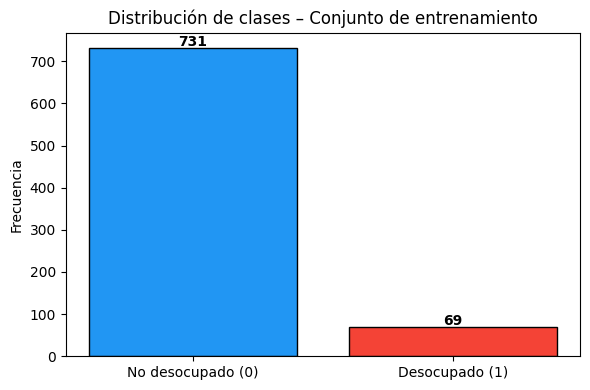

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts().sort_index()
ax.bar(['No desocupado (0)', 'Desocupado (1)'], counts.values,
       color=['#2196F3', '#F44336'], edgecolor='black')
ax.set_title('Distribución de clases – Conjunto de entrenamiento')
ax.set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. SMOTE – Synthetic Minority Over-sampling Technique

Genera muestras sintéticas de la clase minoritaria interpolando entre vecinos cercanos.

In [3]:
if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_smote, y_smote = smote.fit_resample(X_train, y_train)
    print(f'Después de SMOTE: {X_smote.shape[0]:,} filas')
    print(f'Distribución:\n{pd.Series(y_smote).value_counts()}')
else:
    # Fallback: oversampling simple con numpy
    minority_idx = np.where(y_train == 1)[0]
    majority_idx = np.where(y_train == 0)[0]
    n_resample = len(majority_idx) - len(minority_idx)
    oversampled_idx = np.random.choice(minority_idx, size=n_resample, replace=True)
    X_smote = pd.concat([X_train, X_train.iloc[oversampled_idx]], ignore_index=True)
    y_smote = pd.concat([y_train, y_train.iloc[oversampled_idx]], ignore_index=True)
    print(f'Oversampling simple aplicado. Nuevas filas: {X_smote.shape[0]:,}')
    print(f'Distribución:\n{y_smote.value_counts()}')

Oversampling simple aplicado. Nuevas filas: 1,462
Distribución:
target_desocupado
0    731
1    731
Name: count, dtype: int64


## 3. Random Undersampling (alternativa)

In [4]:
if IMBLEARN_AVAILABLE:
    rus = RandomUnderSampler(random_state=42)
    X_under, y_under = rus.fit_resample(X_train, y_train)
    print(f'Después de Undersampling: {X_under.shape[0]:,} filas')
    print(f'Distribución:\n{pd.Series(y_under).value_counts()}')
else:
    n_minority = int(y_train.sum())
    majority_idx = np.where(y_train == 0)[0]
    selected_majority = np.random.choice(majority_idx, size=n_minority, replace=False)
    minority_idx = np.where(y_train == 1)[0]
    keep_idx = np.concatenate([selected_majority, minority_idx])
    X_under = X_train.iloc[keep_idx].reset_index(drop=True)
    y_under = y_train.iloc[keep_idx].reset_index(drop=True)
    print(f'Undersampling simple aplicado. Filas: {X_under.shape[0]:,}')
    print(f'Distribución:\n{y_under.value_counts()}')

Undersampling simple aplicado. Filas: 138
Distribución:
target_desocupado
0    69
1    69
Name: count, dtype: int64


## 4. Selección de la estrategia y guardado

Para este proyecto se opta por **SMOTE** (oversampling) porque preserva la información de la clase mayoritaria.

In [5]:
# Guardar el dataset balanceado (training set)
BALANCED_DIR = os.path.join('..', 'data', 'balanced')
os.makedirs(BALANCED_DIR, exist_ok=True)

pd.DataFrame(X_smote).to_csv(os.path.join(BALANCED_DIR, 'X_train_balanced.csv'), index=False)
pd.Series(y_smote, name='target_desocupado').to_csv(
    os.path.join(BALANCED_DIR, 'y_train_balanced.csv'), index=False
)
print('Dataset balanceado guardado en:', BALANCED_DIR)

Dataset balanceado guardado en: ..\data\balanced
